# Hugging Face: предобученные модели для разных задач

Этот блокнот подготовлен для демонстрации на занятии. Он показывает, как пользоваться экосистемой **Hugging Face** и применять предобученные модели для разных задач без обучения с нуля.

Основные библиотеки:

- `transformers` — модели, токенизаторы, `pipeline`;
- `datasets` — загрузка и обработка датасетов;
- `evaluate` — метрики;
- `huggingface_hub` — работа с Hugging Face Hub.

В блокноте есть примеры для:

- классификации текста;
- zero-shot классификации;
- распознавания именованных сущностей;
- вопросно-ответных систем;
- заполнения пропусков;
- генерации текста;
- суммаризации;
- перевода;
- эмбеддингов предложений;
- классификации изображений;
- распознавания речи;
- загрузки датасетов;
- базовой идеи fine-tuning.

## План занятия

| Этап | Содержание |
|---|---|
| 1 | Что такое Hugging Face Hub |
| 2 | Библиотека `transformers` и объект `pipeline` |
| 3 | NLP-задачи на предобученных моделях |
| 4 | Эмбеддинги и semantic similarity |
| 5 | Computer Vision и Audio |
| 6 | Библиотека `datasets` |
| 7 | Что такое fine-tuning |

Главная идея:

$$
\text{предобученная модель} + \text{адаптация к задаче} \rightarrow \text{практическое решение}.
$$

Предобучение дорогое, а использование готовой модели часто позволяет быстро собрать рабочий прототип.

## 1. Установка библиотек

Если вы запускаете блокнот в новой среде, выполните ячейку ниже.

`torch` используется потому, что большинство моделей Hugging Face по умолчанию работают через PyTorch. Даже если вы привыкли к TensorFlow, для демонстрации Hugging Face `pipeline` PyTorch часто удобнее.

In [ ]:
%pip install -q transformers datasets evaluate accelerate sentencepiece pillow soundfile librosa torch torchvision torchaudio

In [3]:
import os
import random
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO

import torch
from datasets import load_dataset
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoModelForQuestionAnswering, 
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)


SEED = 42


def set_global_seed(seed):
    """
    Фиксирует генераторы случайных чисел.

    Аргументы:
        seed: целое число для инициализации генераторов.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else -1

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("pipeline device:", DEVICE)

PyTorch: 2.10.0+cu128
CUDA available: True
pipeline device: 0


## 2. Hugging Face Hub: что лежит в экосистеме

Hugging Face Hub можно воспринимать как репозиторий артефактов машинного обучения.

На Hub хранятся:

- модели;
- токенизаторы;
- датасеты;
- демо-приложения Spaces;
- model cards и dataset cards;
- веса, конфиги и вспомогательные файлы.

Типичный путь работы:

1. найти подходящую модель;
2. посмотреть model card;
3. проверить входной формат и ограничения;
4. загрузить модель через `pipeline` или `AutoModel`;
5. применить к своим данным;
6. при необходимости дообучить.

## 3. `pipeline`: самый быстрый способ применить модель

`pipeline` автоматически подбирает:

- токенизатор;
- модель;
- препроцессинг входа;
- постпроцессинг выхода.

Общая форма:

```python
pipe = pipeline(task="...", model="...")
pipe(input_data)
```

Это лучший способ начать демонстрацию, потому что студенты сразу видят практический результат.

# Часть A. NLP-задачи

Начнем с задач обработки текста. Для некоторых задач используем англоязычные модели, потому что они маленькие, стабильные и хорошо подходят для демонстрации.

При работе с русским языком важно выбирать модель, которая обучалась на русском или мультиязычных данных.

## 4. Классификация текста: sentiment analysis

Задача:

$$
f_\theta(\text{text}) \rightarrow \text{label}.
$$

Пример: определить, положительный или отрицательный отзыв.

In [4]:
sentiment_pipe = pipeline(
    task="text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=DEVICE,
)

texts = [
    "The lecture was clear and surprisingly useful.",
    "The model is slow and the result is disappointing.",
]

sentiment_pipe(texts)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9996570348739624},
 {'label': 'NEGATIVE', 'score': 0.999803364276886}]

## 5. Zero-shot классификация

Zero-shot классификация позволяет классифицировать текст по меткам, которые модель не видела как отдельную supervised-задачу.

Идея: модель проверяет, насколько текст согласуется с гипотезой вида:

$$
\text{This text is about } c.
$$

Это удобно, когда у нас нет размеченного датасета.

Модель `facebook/bart-large-mnli` довольно крупная. На слабой машине эта ячейка может выполняться дольше остальных.

In [5]:
zero_shot_pipe = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
)

sequence = "A student is learning how transformers are used in natural language processing."
candidate_labels = ["education", "sports", "finance", "medicine"]

zero_shot_pipe(sequence, candidate_labels)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'A student is learning how transformers are used in natural language processing.',
 'labels': ['education', 'sports', 'medicine', 'finance'],
 'scores': [0.9623385667800903,
  0.015602300874888897,
  0.01454055868089199,
  0.007518550381064415]}

## 6. Named Entity Recognition

NER выделяет сущности:

- людей;
- организации;
- локации;
- даты;
- другие типы объектов.

Результат обычно возвращается на уровне токенов. Параметр `aggregation_strategy="simple"` объединяет токены в более удобные фрагменты.

In [6]:
ner_pipe = pipeline(
    task="token-classification",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=DEVICE,
)

ner_text = "Hugging Face was founded in New York and is widely used by researchers at Stanford University."

ner_pipe(ner_text)

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'entity_group': 'ORG',
  'score': np.float32(0.7993979),
  'word': 'Hugging Face',
  'start': 0,
  'end': 12},
 {'entity_group': 'LOC',
  'score': np.float32(0.99937534),
  'word': 'New York',
  'start': 28,
  'end': 36},
 {'entity_group': 'ORG',
  'score': np.float32(0.9974772),
  'word': 'Stanford University',
  'start': 74,
  'end': 93}]

## 7. Question Answering

В question answering модель получает:

- вопрос;
- контекст.

Затем находит ответ внутри контекста.

$$
f_\theta(\text{question}, \text{context}) \rightarrow \text{answer span}.
$$

In [38]:
model_name = "distilbert-base-cased-distilled-squad"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

context = (
    "Hugging Face is a platform for machine learning models, datasets, and demos. "
    "The Transformers library provides APIs for using pretrained models in NLP, vision, and audio tasks."
)

question = "What does the Transformers library provide?"

inputs = tokenizer(
    question,
    context,
    return_tensors="pt",
    truncation=True,
)

with torch.no_grad():
    outputs = model(**inputs)

start_index = torch.argmax(outputs.start_logits)
end_index = torch.argmax(outputs.end_logits)

answer_ids = inputs["input_ids"][0][start_index : end_index + 1]
answer = tokenizer.decode(answer_ids, skip_special_tokens=True)

answer

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

'APIs'

## 8. Fill-mask

Маскированная языковая модель предсказывает пропущенный токен.

Это полезно для объяснения идеи предобучения BERT-подобных моделей:

$$
P(x_{\mathrm{masked}} \mid x_{\mathrm{context}}).
$$

In [18]:
fill_mask_pipe = pipeline(
    task="fill-mask",
    model="distilroberta-base",
    device=DEVICE,
)

fill_mask_pipe("Transformers are powerful models for <mask> processing.", top_k=5)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

[transformers] RobertaForMaskedLM LOAD REPORT from: distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.1478898674249649,
  'token': 2274,
  'token_str': ' image',
  'sequence': 'Transformers are powerful models for image processing.'},
 {'score': 0.07915566116571426,
  'token': 414,
  'token_str': ' data',
  'sequence': 'Transformers are powerful models for data processing.'},
 {'score': 0.06216840073466301,
  'token': 6029,
  'token_str': ' signal',
  'sequence': 'Transformers are powerful models for signal processing.'},
 {'score': 0.02866445481777191,
  'token': 26739,
  'token_str': ' neural',
  'sequence': 'Transformers are powerful models for neural processing.'},
 {'score': 0.02702624723315239,
  'token': 12774,
  'token_str': ' graphics',
  'sequence': 'Transformers are powerful models for graphics processing.'}]

## 9. Text generation

Генеративная языковая модель продолжает текст:

$$
P(x_t \mid x_1, x_2, \ldots, x_{t-1}).
$$

Для короткой демонстрации используем `distilgpt2`.

In [39]:
generation_pipe = pipeline(
    task="text-generation",
    model="distilgpt2",
    device=DEVICE,
)

generation_pipe(
    "In a practical machine learning course, students should learn",
    max_new_tokens=40,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
    num_return_sequences=2,
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'top_p', 'num_return_sequences', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "In a practical machine learning course, students should learn about machine learning software, and learn about it.\n\n\n\nThis post is part of a series by the University of Chicago's Computer Science Program and the Computer Science Institute's Program on Machine Learning"},
 {'generated_text': 'In a practical machine learning course, students should learn to apply for a computer science degree by applying to a machine learning course on top of their work and learning. We also encourage students to apply online to other computer science programs for a computer science degree in'}]

# Часть B. Токенизаторы и модели вручную

`pipeline` удобен, но иногда нужно контролировать процесс:

- посмотреть токены;
- получить logits;
- извлечь embeddings;
- написать собственную функцию постобработки.

Для этого используют `AutoTokenizer` и `AutoModel`.

## 12. Токенизация

Токенизатор переводит текст в числовые идентификаторы:

$$
\text{tokenizer}(\text{text}) = [ \text{id}_1, \text{id}_2, \dots, \text{id}_n ]
$$

Модель работает не со строкой, а с последовательностью чисел.

In [44]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_text = "Hugging Face makes pretrained models accessible."
encoded = tokenizer(sample_text, return_tensors="pt")

print("Tokens:")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))

print("\nInput IDs:")
print(encoded["input_ids"][0])

print("\nAttention mask:")
print(encoded["attention_mask"][0])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokens:
['[CLS]', 'hugging', 'face', 'makes', 'pre', '##train', '##ed', 'models', 'accessible', '.', '[SEP]']

Input IDs:
tensor([  101, 17662,  2227,  3084,  3653, 23654,  2098,  4275,  7801,  1012,
          102])

Attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


## 13. Получение эмбеддингов предложений

Эмбеддинг — векторное представление текста.

Один простой способ получить embedding предложения:

1. получить скрытые состояния токенов;
2. усреднить их с учетом `attention_mask`.

Это не всегда лучше специализированных sentence-transformer моделей, но хорошо показывает механику.

In [45]:
embedding_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

if torch.cuda.is_available():
    embedding_model = embedding_model.to("cuda")


def mean_pooling(model_output, attention_mask):
    """
    Усредняет токеновые embeddings с учетом attention mask.

    Аргументы:
        model_output: выход AutoModel.
        attention_mask: маска реальных токенов.

    Возвращает:
        Tensor с embedding каждого предложения.
    """
    token_embeddings = model_output.last_hidden_state
    input_mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask, dim=1) / torch.clamp(input_mask.sum(dim=1), min=1e-9)


def encode_sentences(sentences):
    """
    Кодирует список предложений в нормированные embeddings.

    Аргументы:
        sentences: список строк.

    Возвращает:
        numpy-массив embeddings.
    """
    batch = embedding_tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

    if torch.cuda.is_available():
        batch = {key: value.to("cuda") for key, value in batch.items()}

    with torch.no_grad():
        output = embedding_model(**batch)

    embeddings = mean_pooling(output, batch["attention_mask"])
    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

    return embeddings.cpu().numpy()


sentences = [
    "Студенты изучают нейронные сети.",
    "На занятии разбирают глубокое обучение.",
    "Сегодня хорошая погода для прогулки.",
]

embeddings = encode_sentences(sentences)

similarity = embeddings @ embeddings.T
pd.DataFrame(similarity, index=sentences, columns=sentences)

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Студенты изучают нейронные сети.,На занятии разбирают глубокое обучение.,Сегодня хорошая погода для прогулки.
Студенты изучают нейронные сети.,1.000000,0.502904,-0.042890
На занятии разбирают глубокое обучение.,0.502904,1.000000,0.013011
Сегодня хорошая погода для прогулки.,-0.042890,0.013011,1.000000


# Часть C. Computer Vision

Hugging Face поддерживает не только NLP. Через `pipeline` можно использовать модели для изображений.

## 14. Классификация изображений

Для примера загрузим маленький датасет изображений из Hugging Face и классифицируем одно изображение предобученной ViT-моделью.

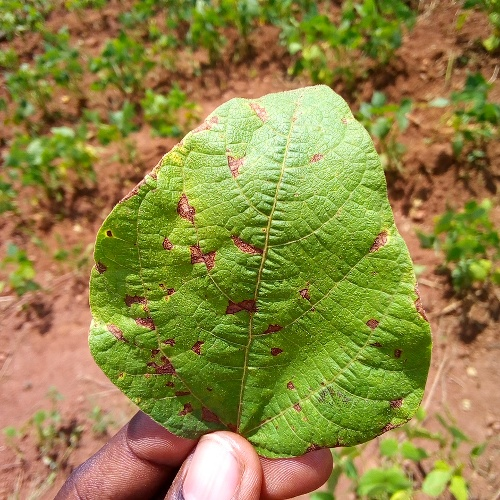

In [2]:
image_dataset = load_dataset("beans", split="validation[:3]")

image = image_dataset[0]["image"]
image

In [3]:
image_classification_pipe = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224",
    device=DEVICE,
)

image_classification_pipe(image)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[{'label': 'leaf beetle, chrysomelid', 'score': 0.17287419736385345},
 {'label': 'lacewing, lacewing fly', 'score': 0.02129698544740677},
 {'label': 'custard apple', 'score': 0.01827387511730194},
 {'label': 'leafhopper', 'score': 0.01824142038822174},
 {'label': 'fig', 'score': 0.016953935846686363}]

# Часть D. Datasets

`datasets` — библиотека для загрузки, фильтрации, преобразования и кэширования датасетов.

Датасет можно загрузить одной строкой:

```python
dataset = load_dataset("name")
```

Многие датасеты уже имеют split-части: `train`, `validation`, `test`.

In [3]:
imdb = load_dataset("imdb", split="train[:1000]")
imdb

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})

In [4]:
imdb_df = imdb.to_pandas()
imdb_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 15. Преобразование датасета через `map`

Метод `map` применяет функцию к каждому примеру.

Ниже добавим длину текста в символах.

In [5]:
def add_text_length(example):
    """
    Добавляет длину текста в символах.

    Аргументы:
        example: один пример из датасета.

    Возвращает:
        Обновленный пример с полем text_length.
    """
    example["text_length"] = len(example["text"])
    return example


imdb_with_length = imdb.map(add_text_length)
imdb_with_length[0]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

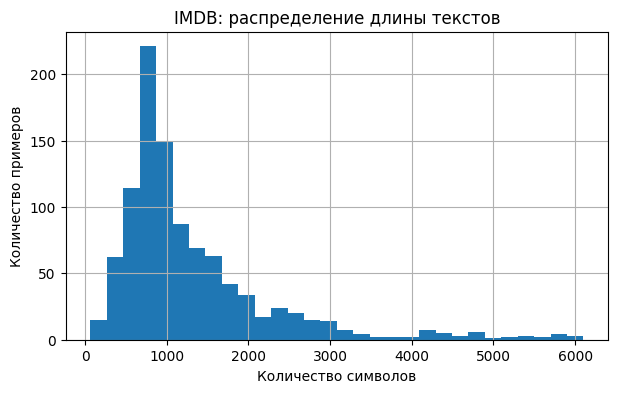

In [6]:
lengths = imdb_with_length["text_length"]

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=30)
plt.title("IMDB: распределение длины текстов")
plt.xlabel("Количество символов")
plt.ylabel("Количество примеров")
plt.grid(True)
plt.show()

# Часть E. Мини-идея fine-tuning

Предобученная модель уже знает много общих языковых закономерностей. Fine-tuning адаптирует ее к конкретной задаче.

Типичный пайплайн:

1. загрузить датасет;
2. токенизировать данные;
3. загрузить `AutoModelFor...`;
4. обучить модель на своей разметке;
5. оценить качество.

Ниже дана компактная заготовка. Ее можно запускать как отдельный практический эксперимент. Для лекции достаточно разобрать код и идею.

In [1]:
import inspect
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
import evaluate

# ======================
# SEED — фиксирует случайность
# ======================
SEED = 42
# Используется для:
# - shuffle датасета
# - reproducibility эксперимента
# В ML это критично для сравнимости результатов

# ======================
# 1. Dataset
# ======================
dataset = load_dataset("imdb")
# Загружает IMDB dataset:
# - 25k train
# - 25k test
# Датасет для бинарной классификации sentiment analysis

tiny_imdb = dataset["train"].shuffle(seed=SEED).select(range(2000))
# Берём только 2000 примеров:
# - ускорение эксперимента
# - но увеличивает variance оценки (меньше данных → шумнее метрики)

tiny_imdb = tiny_imdb.train_test_split(test_size=0.2, seed=SEED)
# Делим 2000 примеров:
# - 1600 train
# - 400 test
# test_size=0.2 → 20% данных уходит на validation

# ======================
# 2. Tokenizer
# ======================
model_name = "distilbert-base-uncased"
# Предобученная модель:
# - DistilBERT (дистиллированный BERT)
# - uncased → игнорирует регистр (Hello == hello)

tokenizer = AutoTokenizer.from_pretrained(model_name)
# Загружает токенизатор:
# - wordpiece tokenization
# - преобразует текст → input_ids

def tokenize(batch):
    return tokenizer(
        batch["text"],      # входной текст
        truncation=True,    # обрезает тексты > max_length
        max_length=256      # максимальная длина последовательности
    )
# truncation=True:
# - предотвращает OOM
# - но может обрезать важный контекст (trade-off)

tokenized = tiny_imdb.map(tokenize, batched=True)
# Применяет токенизацию ко всему датасету
# batched=True → ускоряет обработку (vectorized-like)

# ======================
# Очистка колонок
# ======================
tokenized = tokenized.remove_columns(["text"])
# Удаляем исходный текст:
# - он больше не нужен модели
# - уменьшает memory usage

if "token_type_ids" in tokenized["train"].column_names:
    tokenized = tokenized.remove_columns(["token_type_ids"])
# DistilBERT НЕ использует token_type_ids
# (они нужны BERT для sentence pair tasks)

# ======================
# 3. Data collator
# ======================
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
# Автоматический padding батчей:
# - делает все sequences одинаковой длины в batch
# - динамический padding → экономит память
# - лучше чем static padding

# ======================
# 4. Metrics
# ======================
metric = evaluate.load("accuracy")
# Accuracy = доля правильных предсказаний

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # logits → сырые выходы модели [batch, num_classes]

    preds = np.argmax(logits, axis=1)
    # argmax → выбираем класс с максимальной вероятностью

    return metric.compute(
        predictions=preds,
        references=labels
    )
# Возвращает словарь:
# {"accuracy": значение}

# ======================
# 5. Model
# ======================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
# Загружает DistilBERT + добавляет classification head:
# - linear layer поверх CLS embedding
# - num_labels=2 → binary classification

# ВАЖНО:
# head инициализируется случайно → поэтому loss сначала высокий

# ======================
# 6. Training arguments
# ======================
strategy_argument = (
    "eval_strategy"
    if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters
    else "evaluation_strategy"
)
# Compatibility hack:
# - HF менял API
# - старые версии: evaluation_strategy
# - новые версии: eval_strategy

training_args = TrainingArguments(
    output_dir="hf_demo_imdb_model",
    # куда сохраняются:
    # - чекпоинты
    # - логирование
    # - модель

    learning_rate=2e-5,
    # шаг градиентного спуска:
    # типичный LR для fine-tuning BERT

    per_device_train_batch_size=8,
    # batch size на GPU/CPU
    # маленький batch → шумный gradient, но стабильнее memory

    per_device_eval_batch_size=8,
    # batch size для evaluation

    num_train_epochs=2,
    # сколько раз пройти весь train dataset
    # 2 эпохи → часто достаточно для small dataset

    logging_steps=20,
    # как часто логировать loss/metrics

    save_strategy="no",
    # отключает сохранение чекпоинтов:
    # - быстрее
    # - но нельзя восстановить обучение

    report_to="none",
    # отключает интеграции (wandb, tensorboard)
    # ВАЖНО: также уменьшает вероятность callback багов

    **{strategy_argument: "epoch"},
    # evaluation_strategy:
    # "epoch" → evaluate после каждой эпохи
    # важно для контроля overfitting
)

# ======================
# 7. Trainer
# ======================
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized["train"],
    # обучающая выборка

    eval_dataset=tokenized["test"],
    # validation/test выборка

    data_collator=data_collator,
    # отвечает за batching + padding

    compute_metrics=compute_metrics,
    # функция вычисления accuracy

    callbacks=[]
    # отключает callback систему HF:
    # - убирает NotebookProgressCallback
    # - фиксит баг evaluate в Jupyter
    # - но отключает progress bar и расширенные хуки
)

# ======================
# 8. Train
# ======================
trainer.train()
# запускает training loop:
# - forward pass
# - loss computation (cross-entropy)
# - backpropagation
# - optimizer step (AdamW)
# - evaluation по epoch

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.389178,0.290053,0.892500
2,0.140168,0.326416,0.880000


TrainOutput(global_step=400, training_loss=0.34779237031936644, metrics={'train_runtime': 18.2331, 'train_samples_per_second': 175.505, 'train_steps_per_second': 21.938, 'total_flos': 211664274824352.0, 'train_loss': 0.34779237031936644, 'epoch': 2.0})

In [4]:
pd.DataFrame(trainer.state.log_history)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.679995,1.476319,1.905000e-05,0.1,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.632318,8.493359,1.805000e-05,0.2,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.436654,6.769661,1.705000e-05,0.3,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.371067,21.202002,1.605000e-05,0.4,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.459801,9.128099,1.505000e-05,0.5,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.457496,5.183261,1.405000e-05,0.6,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.385457,4.483870,1.305000e-05,0.7,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.379060,10.592340,1.205000e-05,0.8,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.309060,23.003757,1.105000e-05,0.9,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.389178,14.258789,1.005000e-05,1.0,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Модель DistilBERT была дообучена на задаче бинарной классификации (IMDB sentiment analysis) на небольшой подвыборке (2000 примеров: 1600 train / 400 test) в течение 2 эпох.

Обучение использует AdamW-оптимизацию с линейным decay learning rate и периодической валидацией после каждой эпохи.


Training loss

- Начальное значение: ~0.68  
- Быстрое снижение до: ~0.30–0.45  
- Финальное значение: ~0.14  

Модель быстро адаптируется к задаче, что ожидаемо для fine-tuning pretrained Transformer'а. Основная часть языковых представлений уже обучена, поэтому оптимизируется в основном классификационная голова и верхние слои encoder'а.


Validation metrics

Epoch 1

- eval_loss: 0.290  
- eval_accuracy: 0.8925  

Epoch 2

- eval_loss: 0.326  
- eval_accuracy: 0.8800  

Наблюдается ухудшение качества на валидации после первой эпохи.

Это сигнал начала переобучения:
- validation loss растёт
- accuracy снижается

Переобучение (overfitting)

Поведение модели соответствует классическому сценарию:

- training loss ↓ продолжает снижаться
- validation loss ↑ начинает расти
- validation accuracy ↓ слегка падает

Это означает, что модель начинает запоминать обучающую выборку, теряя способность к обобщению.

Learning rate schedule

Learning rate постепенно уменьшается от ~2e-5 к ~5e-8.

Используется линейное затухание learning rate:
- на старте — быстрые обновления весов
- ближе к концу — стабилизация и тонкая настройка параметров

Это стандартная практика для fine-tuning трансформеров.

Градиенты

- grad_norm варьируется примерно от 0.4 до 23

- значительные колебания норм градиентов допустимы
- признаков нестабильного обучения (exploding gradients) нет
- оптимизация проходит стабильно

Производительность

- ~175 samples/sec (train)
- ~21 steps/sec
- evaluation выполняется быстро (~0.5–0.6s)

Пайплайн не ограничен вычислительно и эффективно использует ресурсы.

# Практические советы

1. Всегда читайте model card: там указаны данные обучения, ограничения и лицензия.
2. Проверяйте язык модели: английская модель может плохо работать на русском тексте.
3. Начинайте с `pipeline`, затем переходите к `AutoTokenizer` и `AutoModel`.
4. Для production учитывайте размер модели, скорость, память и качество.
5. Для учебных занятий выбирайте маленькие модели, чтобы студенты видели результат быстро.
6. Для серьезной задачи сравнивайте несколько моделей и фиксируйте метрики.

# Итоги

В этом блокноте мы:

- познакомились с Hugging Face Hub;
- использовали `pipeline` для разных задач;
- разобрали токенизацию;
- получили embeddings предложений;
- применили модели для изображений и аудио;
- загрузили и обработали датасеты;
- посмотрели структуру базового fine-tuning.

Главная мысль:

> Hugging Face позволяет быстро переходить от идеи к прототипу, но качество решения зависит от правильного выбора модели, данных и метрик.